<b>Cell 1: Import Library</b>

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import joblib # Untuk menyimpan model
from skimage.feature import graycomatrix, graycoprops
from skimage.measure import shannon_entropy
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

<b>Cell 2: Konfigurasi dan Ekstraksi Fitur</b>

In [2]:
# 1. KONFIGURASI FOLDER
main_folder = 'Dataset'
data_type = 'Train'
classList = ['Cloudy', 'Rain', 'Shine']

data_latih = []
target_latih = []

print('--- MEMULAI PROSES EKSTRAKSI FITUR (OPTIMASI TINGGI) ---')

for k, className in enumerate(classList):
    folderPath = os.path.join(main_folder, data_type, className)
    
    # Lewati jika folder tidak ada
    if not os.path.exists(folderPath):
        print(f'Folder tidak ditemukan: {folderPath}')
        continue
        
    files = [f for f in os.listdir(folderPath) if f.lower().endswith('.jpg')]
    
    if not files:
        continue
        
    print(f'Memproses Kelas: {className} ({len(files)} gambar)')
    
    for file in files:
        try:
            img_path = os.path.join(folderPath, file)
            # Baca gambar dengan OpenCV
            img = cv2.imread(img_path)
            if img is None:
                continue
                
            # Resize ke 256x256
            img = cv2.resize(img, (256, 256))
            
            # Konversi BGR ke RGB
            rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            # Konversi ke Grayscale untuk tekstur dan entropi
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            
            # --- EKSTRAKSI FITUR ---
            # Rata-rata RGB
            MeanR = np.mean(rgb_img[:, :, 0])
            MeanG = np.mean(rgb_img[:, :, 1])
            MeanB = np.mean(rgb_img[:, :, 2])
            
            # GLCM Optimization
            # MATLAB Offset [0 1; -1 1; -1 0; -1 -1] setara dengan jarak 1 pada sudut 0, 45, 90, 135 derajat
            angles = [0, np.pi/4, np.pi/2, 3*np.pi/4]
            glcm = graycomatrix(gray, distances=[1], angles=angles, symmetric=True, normed=True)
            
            # Ambil rata-rata dari 4 sudut
            CiriCON = np.mean(graycoprops(glcm, 'contrast'))
            CiriCOR = np.mean(graycoprops(glcm, 'correlation'))
            CiriASM = np.mean(graycoprops(glcm, 'energy')) # Energy setara dengan ASM
            CiriIDM = np.mean(graycoprops(glcm, 'homogeneity')) # Homogeneity setara dengan IDM
            
            # Entropy
            CiriENTR = shannon_entropy(gray)
            
            # Gabungkan fitur ke array
            fitur_temp = [MeanR, MeanG, MeanB, CiriENTR, CiriASM, CiriCON, CiriCOR, CiriIDM]
            data_latih.append(fitur_temp)
            target_latih.append(k) # Target berupa indeks: 0, 1, 2
            
        except Exception as e:
            print(f"Error memproses {file}: {e}")
            continue

# Konversi ke Numpy Array
X = np.array(data_latih)
y = np.array(target_latih)
print(f"Total data latih: {X.shape[0]} sampel dengan {X.shape[1]} fitur.")

--- MEMULAI PROSES EKSTRAKSI FITUR (OPTIMASI TINGGI) ---
Memproses Kelas: Cloudy (160 gambar)
Memproses Kelas: Rain (159 gambar)
Memproses Kelas: Shine (160 gambar)
Total data latih: 479 sampel dengan 8 fitur.


<b>Cell 3: Normalisasi dan Pelatihan Model JST</b>

In [3]:
# --- TAHAP OPTIMASI JST ---

# 2. Normalisasi Data (Kunci Akurasi Tinggi)
# Menskalakan semua fitur ke rentang [-1, 1] seperti mapminmax di MATLAB
scaler = MinMaxScaler(feature_range=(-1, 1))
X_norm = scaler.fit_transform(X)

# (Opsional) Pisahkan data latih dan data uji internal jika dataset besar,
# Tapi karena kita mau meniru MATLAB persis (train di seluruh dataset lalu evaluasi ke set yang sama),
# kita akan gunakan X_norm langsung.

# 3. Membuat Pattern Recognition Network
# Menggunakan MLPClassifier dengan 30 neuron tersembunyi (setara patternnet(30))
net = MLPClassifier(
    hidden_layer_sizes=(30,),
    activation='relu', # Anda bisa bereksperimen dengan 'logistic' atau 'tanh'
    solver='adam',     # Optimizer
    max_iter=1000,     # Epochs (setara net.trainParam.epochs = 1000)
    tol=1e-7,          # Goal/Toleransi (setara net.trainParam.goal = 1e-7)
    learning_rate_init=0.01, # (setara net.trainParam.lr = 0.01)
    random_state=42    # Agar hasil reprodusibel
)

# 4. Proses Training
print("Sedang melatih model JST...")
net.fit(X_norm, y)
print("Pelatihan Selesai!")

# Simpan Model dan Parameter Normalisasi ke file
# Ini setara dengan "save net_cuaca_v2.mat" di MATLAB
joblib.dump(net, 'net_cuaca_python_v2.pkl')
joblib.dump(scaler, 'scaler_cuaca_python_v2.pkl')
joblib.dump(classList, 'classList_python.pkl')
print("Model dan Scaler berhasil disimpan.")

Sedang melatih model JST...
Pelatihan Selesai!
Model dan Scaler berhasil disimpan.


<b>Cell 4: Evaluasi dan Metrik Performa</b>


--- HASIL EVALUASI PER KELAS ---
              precision    recall  f1-score   support

      Cloudy       0.89      0.84      0.86       160
        Rain       0.90      0.92      0.91       159
       Shine       0.90      0.94      0.92       160

    accuracy                           0.90       479
   macro avg       0.90      0.90      0.90       479
weighted avg       0.90      0.90      0.90       479

----------------------------------------
Akurasi Training Setelah Optimasi: 89.77%
----------------------------------------


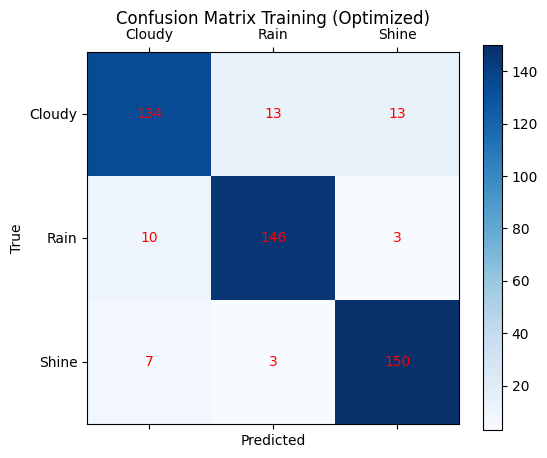

In [4]:
# 5. Evaluasi
output_class = net.predict(X_norm)

print('\n--- HASIL EVALUASI PER KELAS ---')
# Memanfaatkan fungsi classification_report dari scikit-learn
print(classification_report(y, output_class, target_names=classList))

# Confusion Matrix
confMat = confusion_matrix(y, output_class)
accuracy = accuracy_score(y, output_class) * 100

print('-'*40)
print(f'Akurasi Training Setelah Optimasi: {accuracy:.2f}%')
print('-'*40)

# Visualisasi Confusion Matrix menggunakan Matplotlib
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(confMat, cmap=plt.cm.Blues)
plt.title('Confusion Matrix Training (Optimized)', pad=20)
fig.colorbar(cax)

ax.set_xticks(np.arange(len(classList)))
ax.set_yticks(np.arange(len(classList)))
ax.set_xticklabels(classList)
ax.set_yticklabels(classList)
plt.xlabel('Predicted')
plt.ylabel('True')

# Menambahkan teks angka di dalam kotak confusion matrix
for i in range(len(classList)):
    for j in range(len(classList)):
        text = ax.text(j, i, confMat[i, j], ha="center", va="center", color="red")

plt.show()